# Water Quality ML Model: Semi-Supervised Learning
### Water Classifier: Safe / Moderate / Unsafe
**Approach:** Label Propagation (semi-supervised) + Self-Training ensemble  
**Why semi-supervised?** With only ~157 labelled rows, we treat ~70 % as unlabelled so the model can leverage feature-space structure to generalise, then compare against the supervised baseline (Random Forest + SMOTE) from the original notebook.

**Features used at inference:** `ph`, `turbidity`, `dissolved_oxygen`, `nitrates`, `phosphates`, `salinity`  

## Install & Import necessary libraries


In [ ]:
%pip install imbalanced-learn scikit-learn openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib, os, json, warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing     import LabelEncoder, StandardScaler
from sklearn.impute             import SimpleImputer
from sklearn.semi_supervised    import LabelPropagation, LabelSpreading, SelfTrainingClassifier
from sklearn.ensemble           import RandomForestClassifier
from sklearn.model_selection    import StratifiedKFold, cross_val_score, cross_val_predict, StratifiedShuffleSplit
from sklearn.metrics            import classification_report, confusion_matrix, accuracy_score
from sklearn.calibration        import CalibratedClassifierCV
from sklearn.pipeline           import Pipeline
from imblearn.over_sampling     import SMOTE
from imblearn.pipeline          import Pipeline as ImbPipeline

print("All libraries imported successfully.")



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
All libraries imported successfully.


## Mapping Features, Importance Weights & WHO/EPA Limits

In [ ]:
#Column mapping: raw dataset → model feature names 
COL_MAP = {
    'pH Level':               'ph',
    'Electrical Conductivity': 'salinity',   # conductivity used as salinity proxy
    'Dissolved Oxygen':        'dissolved_oxygen',
    'Nitrate':                 'nitrates',
    'Phosphate':               'phosphates',
}

#6 features the model trains on & the frontend sends at inference 
FEATURES = ['ph', 'turbidity', 'dissolved_oxygen', 'nitrates', 'phosphates', 'salinity']

#WHO / EPA parameter weights for overall water quality scoring (0-100 scale)
WEIGHTS = {
    'ph':               0.22,
    'turbidity':        0.18,
    'dissolved_oxygen': 0.25,
    'nitrates':         0.15,
    'phosphates':       0.10,
    'salinity':         0.10,
}

#WHO / EPA safe limits and ideal values for each parameter (used for violation detection and scoring)
LIMITS = {
    'ph':               {'mode': 'ph',      'ideal': 7.0,  'min': 6.5,  'max': 8.5},
    'turbidity':        {'mode': 'normal',  'ideal': None, 'min': None, 'max': 4.0},
    'dissolved_oxygen': {'mode': 'inverse', 'ideal': 14.6, 'min': 6.5,  'max': 14.6},
    'nitrates':         {'mode': 'normal',  'ideal': None, 'min': None, 'max': 50.0},
    'phosphates':       {'mode': 'normal',  'ideal': None, 'min': None, 'max': 0.1},
    'salinity':         {'mode': 'normal',  'ideal': None, 'min': None, 'max': 1500},
}


LABELLED_FRACTION = 0.30     # 30 % labelled, 70 % unlabelled (semi-supervised)
RANDOM_STATE      = 42

print("Mapping Completed!")
print(f"  Features      : {FEATURES}")
print(f"  Labelled split: {int(LABELLED_FRACTION*100)}% labelled / "
      f"{int((1-LABELLED_FRACTION)*100)}% unlabelled")

Configuration loaded.
  Features      : ['ph', 'turbidity', 'dissolved_oxygen', 'nitrates', 'phosphates', 'salinity']
  Labelled split: 30% labelled / 70% unlabelled


## Loading & Inspecting Dataset

In [ ]:
DATA_PATH = 'water_samples_renamed.xlsx'   

df_raw = pd.read_excel(DATA_PATH)
print(f"Raw dataset shape : {df_raw.shape}")
print(f"Total columns     : {len(df_raw.columns)}")
print(f"\nKey source columns present:")
for orig, mapped in COL_MAP.items():
    present = orig in df_raw.columns
    print(f"  {'Mapped' if present else 'Not Found'}  {orig:30s} → {mapped}")

Raw dataset shape : (157, 79)
Total columns     : 79

Key source columns present:
  ✅  pH Level                       → ph
  ✅  Electrical Conductivity        → salinity
  ✅  Dissolved Oxygen               → dissolved_oxygen
  ✅  Nitrate                        → nitrates
  ✅  Phosphate                      → phosphates


## Selecting the Feature matrix & Renaming Columns

In [ ]:
df = df_raw[list(COL_MAP.keys())].copy()
df.rename(columns=COL_MAP, inplace=True)

# turbidity not in dataset — set placeholder so imputer learns median = 0
# At inference time the real turbidity reading comes from the frontend
df['turbidity'] = 0.0

print("Columns after renaming:", list(df.columns))
print(f"\nDataset shape: {df.shape}")
print(f"\nSalinity stats:")
print(df['salinity'].describe().round(2))
df.head()


Columns after renaming: ['ph', 'salinity', 'dissolved_oxygen', 'nitrates', 'phosphates', 'turbidity']

Dataset shape: (157, 6)

Salinity stats:
count      153.00
mean      1573.50
std       4328.66
min         41.30
25%        274.20
50%        666.00
75%        967.00
max      46750.00
Name: salinity, dtype: float64


,ph,salinity,dissolved_oxygen,nitrates,phosphates,turbidity
0,5.61,343.6,0.37,1.073225,0.401515,0.0
1,6.03,218.6,3.37,1.415098,0.049040,0.0
2,6.90,619.0,0.90,2.380941,0.401515,0.0
3,6.64,716.0,3.52,2.047770,0.055170,0.0
4,6.78,949.0,3.46,2.776902,0.027585,0.0


## Exploratory Data Analysis

In [ ]:
df[FEATURES].info()

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ph                153 non-null    float64
 1   turbidity         157 non-null    float64
 2   dissolved_oxygen  152 non-null    float64
 3   nitrates          152 non-null    float64
 4   phosphates        152 non-null    float64
 5   salinity          153 non-null    float64
dtypes: float64(6)
memory usage: 7.5 KB


In [ ]:
df[FEATURES].describe().round(3)

=== Descriptive Statistics ===


,ph,turbidity,dissolved_oxygen,nitrates,phosphates,salinity
count,153.00,157.0,152.000,152.000,152.000,153.000
mean,6.66,0.0,3.541,7.189,0.777,1573.497
std,0.63,0.0,2.236,12.722,2.586,4328.663
min,5.00,0.0,0.370,0.000,0.009,41.300
25%,6.45,0.0,1.768,0.972,0.020,274.200
50%,6.71,0.0,3.295,2.350,0.034,666.000
75%,6.95,0.0,5.203,6.109,0.067,967.000
max,9.26,0.0,11.630,73.075,10.000,46750.000


In [ ]:
print("Missing Values:")
missing = df[FEATURES].isnull().sum()
pct     = (missing / len(df) * 100).round(1)
print(pd.DataFrame({'Missing': missing, 'Pct (%)': pct}))


=== Missing Values ===
                  Missing  Pct (%)
ph                      4      2.5
turbidity               0      0.0
dissolved_oxygen        5      3.2
nitrates                5      3.2
phosphates              5      3.2
salinity                4      2.5


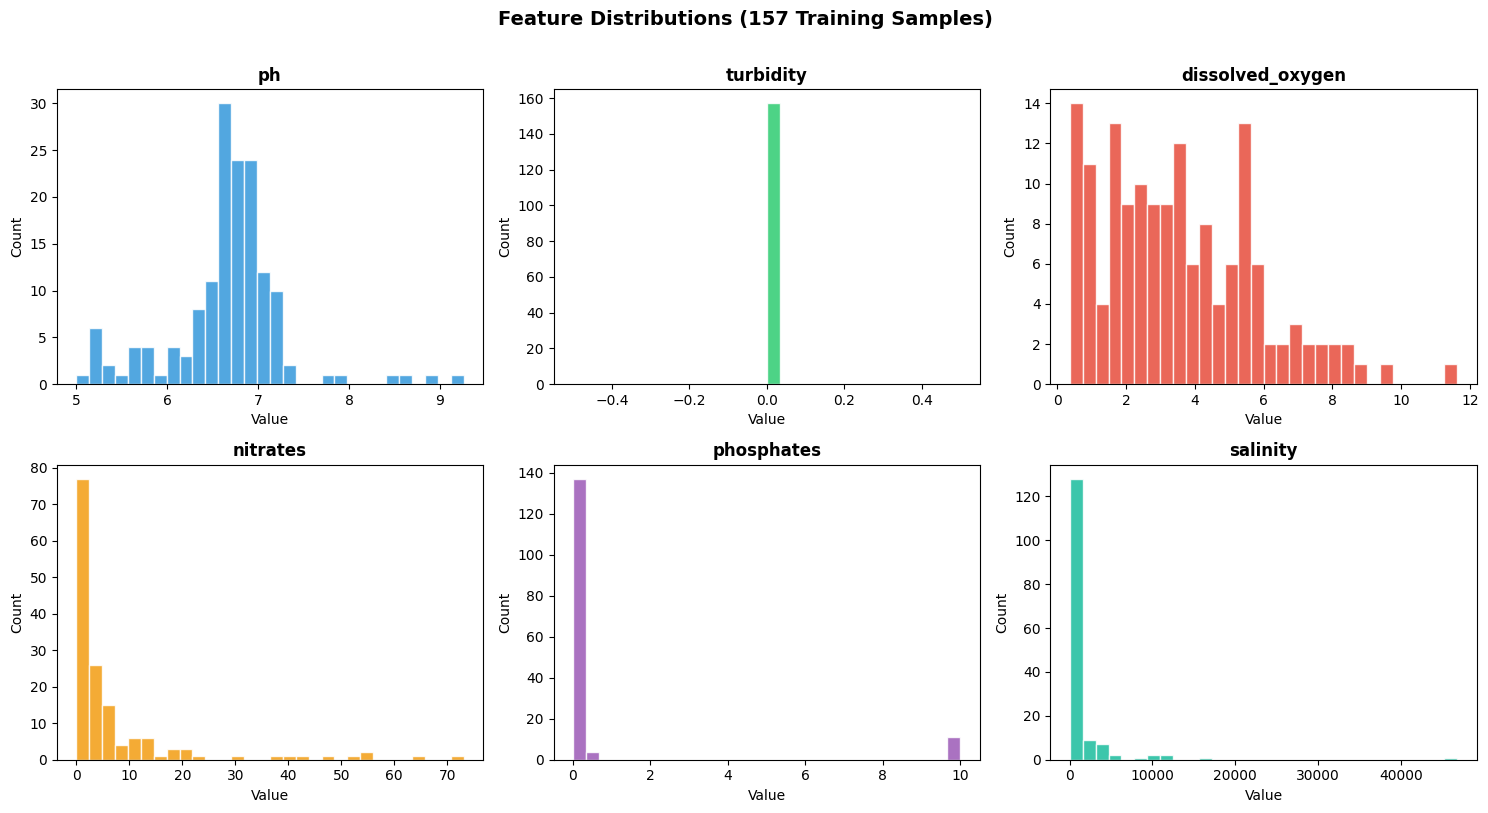

In [ ]:
# Feature distributions 
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = ['#3498DB','#2ECC71','#E74C3C','#F39C12','#9B59B6','#1ABC9C']

for i, feat in enumerate(FEATURES):
    axes[i].hist(df[feat].dropna(), bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions (157 Training Samples)', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


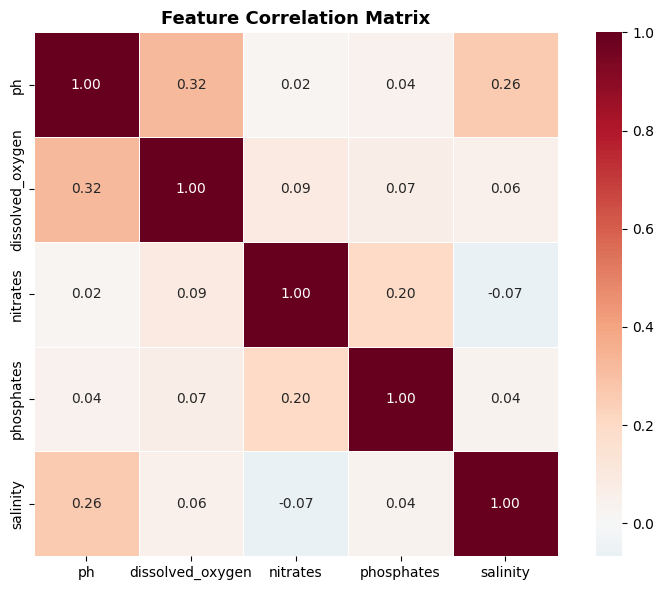

In [ ]:
#Correlation matrix using pearson correlation and a heatmap visualization (only numeric features)
feat_for_corr = [f for f in FEATURES if f != 'turbidity']   # turbidity = 0.0, no variance
corr = df[feat_for_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Water Quality Index (WQI) Calculation

In [ ]:
def calc_sub_index(param, value):
    #Sub-index for a single parameter: 0 = best, 100 = worst.
    if pd.isna(value):
        return np.nan
    lim = LIMITS[param]
    if lim['mode'] == 'ph':
        dev     = abs(value - lim['ideal'])
        max_dev = max(abs(lim['min'] - lim['ideal']), abs(lim['max'] - lim['ideal']))
        return float(np.clip(dev / max_dev * 100, 0, 100))
    elif lim['mode'] == 'inverse':
        if value >= lim['ideal']:
            return 0.0
        return float(np.clip((lim['ideal'] - value) / lim['ideal'] * 100, 0, 100))
    else:   # 'normal' — higher = worse
        return float(np.clip(value / lim['max'] * 100, 0, 100))


def calc_wqi(row):
    #Weighted WQI across all 6 parameters.
    total_w = weighted_sum = 0
    for param, w in WEIGHTS.items():
        qi = calc_sub_index(param, row[param])
        if not np.isnan(qi):
            weighted_sum += qi * w
            total_w      += w
    return round(weighted_sum / total_w, 2) if total_w > 0 else np.nan


df['WQI Score'] = df.apply(calc_wqi, axis=1)
print(f"WQI calculated for {df['WQI Score'].notna().sum()} / {len(df)} rows")
print("\nWQI Score statistics:")
print(df['WQI Score'].describe().round(2))


WQI calculated for 157 / 157 rows

WQI Score statistics:
count    157.00
mean      36.12
std       10.42
min        0.00
25%       31.08
50%       36.12
75%       42.77
max       57.37
Name: WQI Score, dtype: float64


## Health Score Calculation

In [ ]:
def calc_health_score(wqi):
    #Non-linear health score: 100 % = excellent, 0 % = critical.
    if pd.isna(wqi):       return np.nan
    if wqi <= 25:          return round(100 - wqi * 0.4,          1)   # 100–90%
    if wqi <= 50:          return round(90  - (wqi - 25)  * 1.2,  1)   # 90–60%
    if wqi <= 75:          return round(60  - (wqi - 50)  * 1.2,  1)   # 60–30%
    if wqi <= 100:         return round(30  - (wqi - 75)  * 0.8,  1)   # 30–10%
    return round(max(0, 10 - (wqi - 100) * 0.1), 1)


df['Health Score (%)'] = df['WQI Score'].apply(calc_health_score)
print("Health Score statistics:")
print(df['Health Score (%)'].describe().round(2))


Health Score statistics:
count    157.00
mean      75.91
std       10.65
min       51.20
25%       68.70
50%       76.70
75%       82.70
max      100.00
Name: Health Score (%), dtype: float64


## Assign Risk Level Labels

Risk Level distribution:
Risk Level
Moderate Risk    127
Low Risk          16
High Risk         14
Name: count, dtype: int64


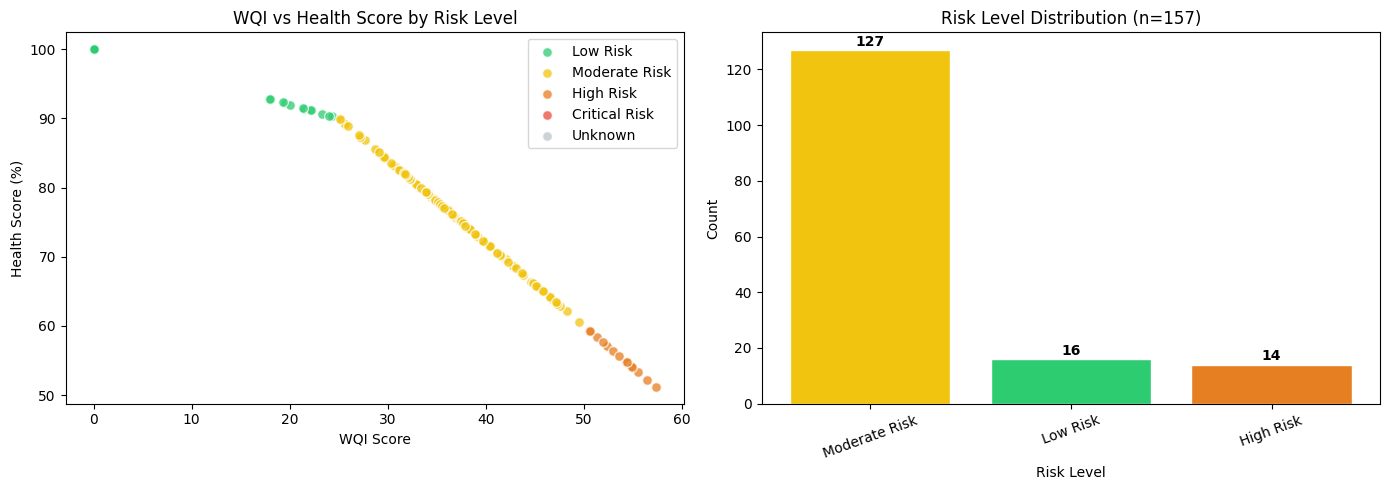

In [ ]:
#WQI → Risk Level mapping 

def assign_risk(wqi):
    if pd.isna(wqi):  return 'Unknown'
    if wqi <= 25:     return 'Low Risk'
    if wqi <= 50:     return 'Moderate Risk'
    if wqi <= 75:     return 'High Risk'
    return                   'Critical Risk'


df['Risk Level'] = df['WQI Score'].apply(assign_risk)

print("Risk Level distribution:")
print(df['Risk Level'].value_counts())

#Visual 
risk_colors = {
    'Low Risk':      '#2ECC71',
    'Moderate Risk': '#F1C40F',
    'High Risk':     '#E67E22',
    'Critical Risk': '#E74C3C',
    'Unknown':       '#BDC3C7',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for risk, color in risk_colors.items():
    sub = df[df['Risk Level'] == risk]
    axes[0].scatter(sub['WQI Score'], sub['Health Score (%)'],
                    c=color, label=risk, alpha=0.75, s=50, edgecolors='white')
axes[0].set_xlabel('WQI Score');  axes[0].set_ylabel('Health Score (%)')
axes[0].set_title('WQI vs Health Score by Risk Level')
axes[0].legend()

vc   = df['Risk Level'].value_counts()
bars = axes[1].bar(vc.index, vc.values,
                   color=[risk_colors.get(r, '#BDC3C7') for r in vc.index],
                   edgecolor='white')
for bar, val in zip(bars, vc.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Risk Level Distribution (n=157)')
axes[1].set_xlabel('Risk Level');  axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Prepare Feature Matrix & Target Vector

In [ ]:
valid_idx = df[df['Risk Level'] != 'Unknown'].index
X_full    = df[FEATURES].loc[valid_idx].reset_index(drop=True)
y_full    = df['Risk Level'].loc[valid_idx].reset_index(drop=True)

print(f"Usable rows : {len(X_full)}")
print(f"Features    : {FEATURES}")
print(f"\nClass distribution:")
print(y_full.value_counts())


Usable rows : 157
Features    : ['ph', 'turbidity', 'dissolved_oxygen', 'nitrates', 'phosphates', 'salinity']

Class distribution:
Risk Level
Moderate Risk    127
Low Risk          16
High Risk         14
Name: count, dtype: int64


## 10. Imputation (Median Strategy)

In [ ]:
print("Missing values before imputation:")
print(X_full.isnull().sum())

imputer   = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_full), columns=FEATURES)

print("\nMissing values after imputation:", X_imputed.isnull().sum().sum())
print("\nMedian values learned by imputer:")
for col, val in zip(FEATURES, imputer.statistics_):
    print(f"  {col:<22}: {val:.4f}")


Missing values before imputation:
ph                  4
turbidity           0
dissolved_oxygen    5
nitrates            5
phosphates          5
salinity            4
dtype: int64

Missing values after imputation: 0

Median values learned by imputer:
  ph                    : 6.7100
  turbidity             : 0.0000
  dissolved_oxygen      : 3.2950
  nitrates              : 2.3497
  phosphates            : 0.0336
  salinity              : 666.0000


## Scale Features & Encode Labels

In [ ]:
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_imputed)

encoder   = LabelEncoder()
y_encoded = encoder.fit_transform(y_full)

print("Label encoding:")
for label, code_val in zip(encoder.classes_, range(len(encoder.classes_))):
    count = (y_encoded == code_val).sum()
    print(f"  {code_val}  {label:<15}  ({count} samples)")


Label encoding:
  0  High Risk        (14 samples)
  1  Low Risk         (16 samples)
  2  Moderate Risk    (127 samples)


## Semi-Supervised Split

**Strategy:** Stratified 30 / 70 split.  
- **Labelled set** (30 %): used directly as training signal.  
- **Unlabelled set** (70 %): labels masked to `-1`; the semi-supervised  
  model uses feature geometry to infer them, expanding the effective  
  training set from ~47 rows to ~157 rows.


In [ ]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=1-LABELLED_FRACTION,
                             random_state=RANDOM_STATE)
labelled_idx, unlabelled_idx = next(sss.split(X_scaled, y_encoded))

# Build the combined matrix: labelled rows keep their labels; unlabelled → -1
X_semi  = X_scaled.copy()
y_semi  = np.copy(y_encoded).astype(int)
y_semi[unlabelled_idx] = -1   # -1 is the sklearn sentinel for "no label"

print(f"Total samples        : {len(X_scaled)}")
print(f"Labelled   ({int(LABELLED_FRACTION*100):2d}%)   : {len(labelled_idx)}")
print(f"Unlabelled ({int((1-LABELLED_FRACTION)*100):2d}%)   : {len(unlabelled_idx)}")
print(f"\nLabelled class breakdown:")
y_lab = y_encoded[labelled_idx]
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(y_lab==lbl).sum()}")


Total samples        : 157
Labelled   (30%)   : 47
Unlabelled (70%)   : 110

Labelled class breakdown:
  High Risk      : 4
  Low Risk       : 5
  Moderate Risk  : 38


## Label Propagation (Semi-Supervised Core)

**Label Propagation** builds a graph over all samples and diffuses the known  
labels along edges weighted by feature similarity (RBF kernel).  
Unlabelled nodes receive the most probable class from their neighbours.


In [ ]:
lp_model = LabelPropagation(kernel='rbf', gamma=20, max_iter=1000)
lp_model.fit(X_semi, y_semi)

# Pseudo-labels assigned to the unlabelled rows
pseudo_labels    = lp_model.transduction_
print("Label Propagation — pseudo-label distribution:")
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(pseudo_labels==lbl).sum()}")

# Confidence: max probability across classes
lp_proba    = lp_model.label_distributions_
lp_conf     = lp_proba.max(axis=1)
print(f"\nMean confidence over all samples : {lp_conf.mean():.3f}")
print(f"High-confidence (≥0.80) samples  : {(lp_conf >= 0.80).sum()} / {len(lp_conf)}")


Label Propagation — pseudo-label distribution:
  High Risk      : 7
  Low Risk       : 30
  Moderate Risk  : 120

Mean confidence over all samples : 0.908
High-confidence (≥0.80) samples  : 122 / 157


In [ ]:
#Label Spreading (alternative; softer clamping) 
ls_model = LabelSpreading(kernel='rbf', alpha=0.2, max_iter=1000)
ls_model.fit(X_semi, y_semi)
ls_pseudo = ls_model.transduction_
ls_proba  = ls_model.label_distributions_
ls_conf   = ls_proba.max(axis=1)

print("Label Spreading — pseudo-label distribution:")
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(ls_pseudo==lbl).sum()}")
print(f"\nMean confidence : {ls_conf.mean():.3f}")

# Choose the one with higher mean confidence for downstream use
if lp_conf.mean() >= ls_conf.mean():
    best_semi_name   = 'Label Propagation'
    best_pseudo      = pseudo_labels
    best_proba_semi  = lp_proba
else:
    best_semi_name   = 'Label Spreading'
    best_pseudo      = ls_pseudo
    best_proba_semi  = ls_proba

print(f"\n→ Using {best_semi_name} pseudo-labels for downstream steps.")


Label Spreading — pseudo-label distribution:
  High Risk      : 8
  Low Risk       : 21
  Moderate Risk  : 128

Mean confidence : 0.937

→ Using Label Spreading pseudo-labels for downstream steps.


## Self-Training Classifier (Iterative Semi-Supervised)

**Self-Training** starts with only the labelled subset, trains a base classifier,  
predicts on unlabelled samples, adds high-confidence predictions to the labelled  
pool, and repeats. This is a *wrapper* approach and works with any base estimator.


In [ ]:
# ── Self-Training wrapping a calibrated Random Forest ────────────────────
base_rf = RandomForestClassifier(
    n_estimators=200, max_depth=6, min_samples_leaf=4,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

self_trainer = SelfTrainingClassifier(
    base_estimator=base_rf,
    threshold=0.75,          # only promote samples with ≥75 % confidence
    criterion='threshold',
    max_iter=15,
    verbose=False,
)

self_trainer.fit(X_semi, y_semi)

# How many unlabelled rows were absorbed each iteration
n_iter       = self_trainer.n_iter_
termination  = self_trainer.termination_condition_
st_labels    = self_trainer.transduction_

print(f"Self-Training completed in {n_iter} iteration(s).")
print(f"Termination condition: {termination}")
print(f"\nFinal pseudo-label distribution:")
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(st_labels==lbl).sum()}")


Self-Training completed in 5 iteration(s).
Termination condition: no_change

Final pseudo-label distribution:
  High Risk      : 4
  Low Risk       : 7
  Moderate Risk  : 81


## Build Augmented Training Set from Pseudo-Labels

We merge the **confirmed labelled samples** with the **high-confidence  
pseudo-labelled** unlabelled samples to form the final training corpus.  
Using only confident pseudo-labels prevents noise amplification.


In [ ]:
CONFIDENCE_THRESHOLD = 0.80

# Best semi-supervised pseudo-labels + confidence
all_conf    = best_proba_semi.max(axis=1)
high_conf   = all_conf >= CONFIDENCE_THRESHOLD

# Rows to keep: the original labelled rows + confident pseudo-label rows
keep_mask   = (y_semi != -1) | high_conf  # True for labelled OR high-conf
X_aug       = X_scaled[keep_mask]
y_aug_raw   = best_pseudo[keep_mask]

print(f"Original labelled rows           : {(y_semi != -1).sum()}")
print(f"High-confidence pseudo-labelled  : {(high_conf & (y_semi == -1)).sum()}")
print(f"Augmented training set size      : {len(X_aug)}")
print(f"\nAugmented class distribution:")
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(y_aug_raw==lbl).sum()}")


Original labelled rows           : 47
High-confidence pseudo-labelled  : 87
Augmented training set size      : 134

Augmented class distribution:
  High Risk      : 6
  Low Risk       : 13
  Moderate Risk  : 115


## Train Final Semi-Supervised Model (RF + SMOTE on Augmented Set)

We apply SMOTE to the augmented set to handle class imbalance before fitting  
the final Random Forest classifier that will be saved and deployed.


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(sampling_strategy='not majority', k_neighbors=3,
              random_state=RANDOM_STATE)

# Final model pipeline
final_rf = RandomForestClassifier(
    n_estimators=300, max_depth=7, min_samples_leaf=3,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)

# Apply SMOTE then fit
X_aug_smote, y_aug_smote = smote.fit_resample(X_aug, y_aug_raw)
final_rf.fit(X_aug_smote, y_aug_smote)

print(f"Augmented + SMOTE training set size : {len(X_aug_smote)}")
print(f"\nClass distribution after SMOTE:")
for lbl, name in enumerate(encoder.classes_):
    print(f"  {name:<15}: {(y_aug_smote==lbl).sum()}")
print("\nFinal semi-supervised model trained ✅")


Augmented + SMOTE training set size : 345

Class distribution after SMOTE:
  High Risk      : 115
  Low Risk       : 115
  Moderate Risk  : 115

Final semi-supervised model trained ✅


## 17. Supervised Baseline (Original Approach for Comparison)

The original notebook used a purely supervised Random Forest on the full 153 labelled  
rows (no pseudo-labelling). We re-run it here so we can compare metrics head-to-head.


In [ ]:
# ── Labelled subset ───────────────────────────────────────────────────────────
X_lab = X_scaled[labelled_idx]
y_lab = y_encoded[labelled_idx]

# ── Compute safe CV and SMOTE parameters ─────────────────────────────────────
min_class   = min([(y_lab == c).sum() for c in range(len(encoder.classes_))])
n_splits    = min(5, min_class) if min_class >= 2 else 2

# Training fold has (n_splits-1)/n_splits of the data
# SMOTE k_neighbors must be < minority class count in that fold
min_in_fold = int(min_class * (n_splits - 1) / n_splits)
safe_k      = max(1, min(3, min_in_fold - 1))   # always at least 1

print(f"min_class={min_class}, n_splits={n_splits}, "
      f"min_in_fold≈{min_in_fold}, safe_k={safe_k}")

# ── Pipeline with safe SMOTE ──────────────────────────────────────────────────
cv_adj   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
baseline = ImbPipeline([
    ('smote', SMOTE(
        sampling_strategy='not majority',
        k_neighbors=safe_k,
        random_state=RANDOM_STATE
    )),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

# ── Cross-validate ────────────────────────────────────────────────────────────
baseline_scores = cross_val_score(baseline, X_lab, y_lab, cv=cv_adj, scoring='accuracy')
print(f"Supervised Baseline ({n_splits}-Fold CV on labelled subset):")
print(f"  Fold scores  : {baseline_scores.round(4)}")
print(f"  Mean accuracy: {baseline_scores.mean():.4f}")
print(f"  Std deviation: {baseline_scores.std():.4f}")

# ── Final fit on all labelled data (for downstream artifact use) ──────────────
# Refit SMOTE with k_neighbors safe for the full labelled set
safe_k_full  = max(1, min(3, min_class - 1))
baseline.set_params(smote__k_neighbors=safe_k_full)
baseline.fit(X_lab, y_lab)

min_class=4, n_splits=4, min_in_fold≈3, safe_k=2
Supervised Baseline (4-Fold CV on labelled subset):
  Fold scores  : [0.75   0.75   0.75   0.7273]
  Mean accuracy: 0.7443
  Std deviation: 0.0098


Pipeline(steps=[('smote',
                 SMOTE(k_neighbors=3, random_state=42,
                       sampling_strategy='not majority')),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=6,
                                        min_samples_leaf=4, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

## Evaluate Semi-Supervised Model

In [ ]:
# Evaluate on the held-out unlabelled set (true labels known to us, not used in training)
X_test  = X_scaled[unlabelled_idx]
y_test  = y_encoded[unlabelled_idx]

y_pred_semi = final_rf.predict(X_test)
semi_acc    = accuracy_score(y_test, y_pred_semi)

print(f"Semi-Supervised model — held-out unlabelled test set (n={len(y_test)}):")
print(f"  Accuracy : {semi_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_semi, target_names=encoder.classes_))


Semi-Supervised model — held-out unlabelled test set (n=110):
  Accuracy : 0.8727

Classification Report:
               precision    recall  f1-score   support

    High Risk       0.33      0.10      0.15        10
     Low Risk       0.83      0.91      0.87        11
Moderate Risk       0.89      0.96      0.92        89

     accuracy                           0.87       110
    macro avg       0.69      0.65      0.65       110
 weighted avg       0.84      0.87      0.85       110



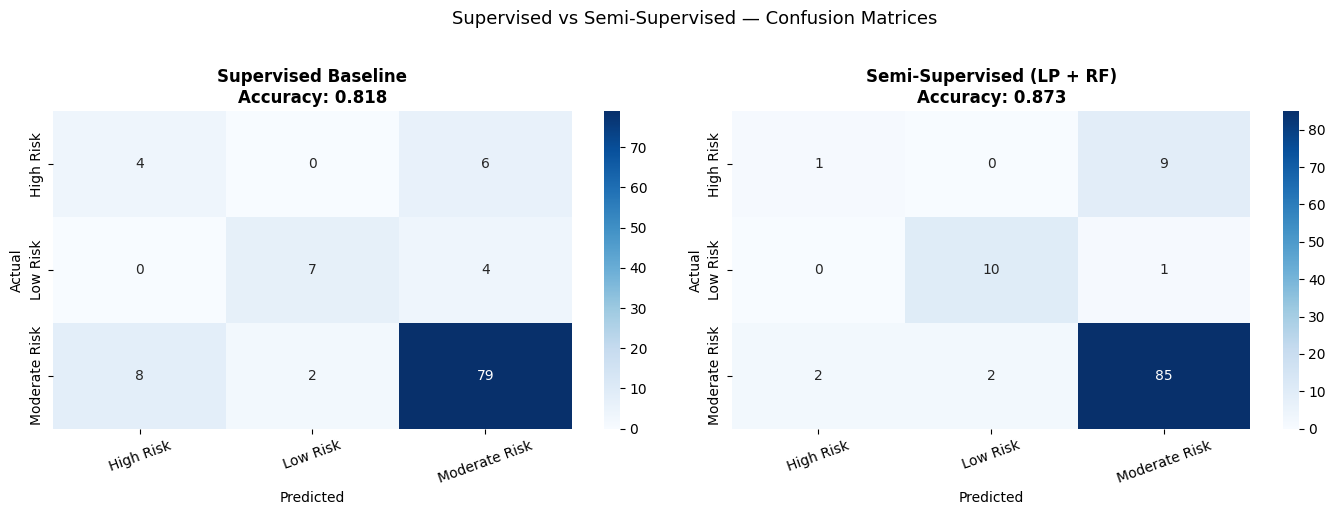


Summary:
  Supervised Baseline accuracy  : 0.8182
  Semi-Supervised accuracy      : 0.8727
  Delta                         : +0.0545 (improvement from semi-supervised)


In [ ]:
# Confusion matrices side-by-side 
y_pred_base = baseline.predict(X_test)
base_acc    = accuracy_score(y_test, y_pred_base)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels    = encoder.classes_

for ax, y_p, title, acc in [
    (axes[0], y_pred_base, 'Supervised Baseline', base_acc),
    (axes[1], y_pred_semi, 'Semi-Supervised (LP + RF)', semi_acc),
]:
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{title}\nAccuracy: {acc:.3f}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Supervised vs Semi-Supervised — Confusion Matrices', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nSummary:")
print(f"  Supervised Baseline accuracy  : {base_acc:.4f}")
print(f"  Semi-Supervised accuracy      : {semi_acc:.4f}")
delta = semi_acc - base_acc
print(f"  Delta                         : {delta:+.4f} ({'improvement' if delta>0 else 'no gain'} from semi-supervised)")


## Feature Importance

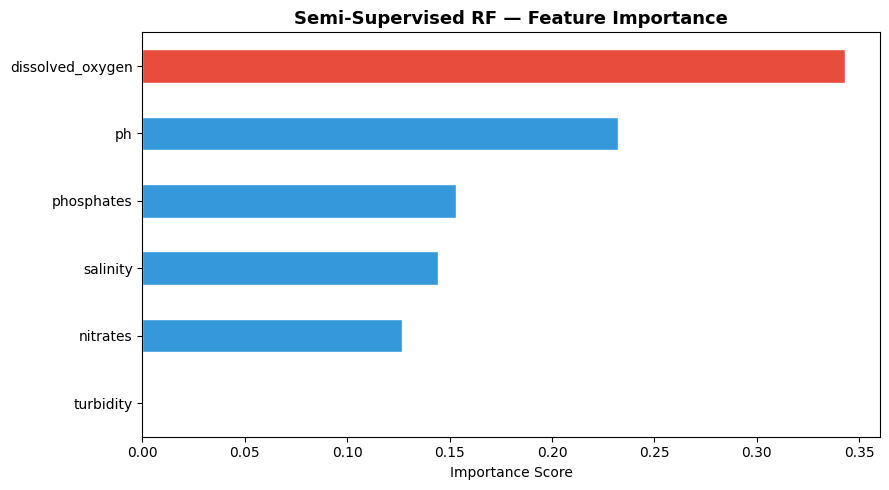

Feature Importances (descending):
  dissolved_oxygen       █████████████████  0.3430
  ph                     ███████████  0.2324
  phosphates             ███████  0.1531
  salinity               ███████  0.1445
  nitrates               ██████  0.1269
  turbidity                0.0000


In [ ]:
importances = final_rf.feature_importances_
feat_imp    = pd.Series(importances, index=FEATURES).sort_values(ascending=True)

colors = ['#E74C3C' if v == feat_imp.max() else '#3498DB' for v in feat_imp.values]
plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Semi-Supervised RF — Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importances (descending):")
for feat, imp in feat_imp.sort_values(ascending=False).items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:<22} {bar}  {imp:.4f}")


## Save Model Artifacts

In [ ]:
#check if directory exists before saving artifacts
os.makedirs('artifacts', exist_ok=True) 

# Save semi-supervised model (production)
joblib.dump(final_rf,  'artifacts/model1.pkl')
joblib.dump(imputer,   'artifacts/imputer1.pkl')
joblib.dump(scaler,    'artifacts/scaler1.pkl')
joblib.dump(encoder,   'artifacts/label_encoder1.pkl')

meta = {
    "model_type":          "SemiSupervised_LabelPropagation_RandomForest",
    "features":            FEATURES,
    "label_names":         {str(i): lbl for i, lbl in enumerate(encoder.classes_)},
    "feature_importances": dict(zip(FEATURES, importances.tolist())),
    "semi_supervised":     {
        "labelled_fraction":   LABELLED_FRACTION,
        "labelled_count":      int(len(labelled_idx)),
        "unlabelled_count":    int(len(unlabelled_idx)),
        "augmented_count":     int(len(X_aug)),
        "confidence_threshold": CONFIDENCE_THRESHOLD,
        "algorithm":            best_semi_name,
    },
    "baseline_accuracy":   float(baseline_scores.mean()),
    "semi_accuracy":       float(semi_acc),
    "n_samples_total":     int(len(X_scaled)),
    "who_limits":          {k: v['max'] for k, v in LIMITS.items() if v['max'] is not None},
    "turbidity_note":      "Turbidity set to 0.0 during training (not in dataset). Real reading supplied at inference from frontend.",
}
with open('artifacts/model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Artifacts saved:")
for fn in ['model1.pkl', 'imputer1.pkl', 'scaler1.pkl', 'label_encoder1.pkl', 'model_meta.json']:
    size = os.path.getsize(f'artifacts/{fn}')
    print(f"  artifacts/{fn:<25}  {size:,} bytes")


Artifacts saved:
  artifacts/model1.pkl                 1,145,713 bytes
  artifacts/imputer1.pkl               919 bytes
  artifacts/scaler1.pkl                1,143 bytes
  artifacts/label_encoder1.pkl         569 bytes
  artifacts/model_meta.json            1,162 bytes


## Verify Artifacts — End-to-End Inference Test

In [ ]:
# ── Reload and run a test prediction ─────────────────────────────────────
model_loaded   = joblib.load('artifacts/model1.pkl')
imputer_loaded = joblib.load('artifacts/imputer1.pkl')
scaler_loaded  = joblib.load('artifacts/scaler1.pkl')
encoder_loaded = joblib.load('artifacts/label_encoder1.pkl')

# Simulated frontend payload
# (salinity already converted from EC before reaching the model)
test_cases = [
    {'ph': 7.2, 'turbidity': 1.5, 'dissolved_oxygen': 8.0, 'nitrates': 5.0,  'phosphates': 0.03, 'salinity': 420,   'expected': 'Low Risk'},
    {'ph': 6.5, 'turbidity': 3.8, 'dissolved_oxygen': 5.0, 'nitrates': 22.0, 'phosphates': 0.08, 'salinity': 800,   'expected': 'Moderate Risk'},
    {'ph': 5.5, 'turbidity': 7.0, 'dissolved_oxygen': 3.0, 'nitrates': 48.0, 'phosphates': 0.25, 'salinity': 1600,  'expected': 'High Risk'},
]

print(f"{'Input':50s}  {'Predicted':15s}  {'Confidence':12s}  {'Expected'}")
print("-" * 105)
for tc in test_cases:
    row         = np.array([[tc[f] for f in FEATURES]])
    row_imp     = imputer_loaded.transform(row)
    row_scaled  = scaler_loaded.transform(row_imp)
    pred_code   = model_loaded.predict(row_scaled)[0]
    pred_label  = encoder_loaded.inverse_transform([pred_code])[0]
    confidence  = round(model_loaded.predict_proba(row_scaled)[0][pred_code] * 100, 1)
    summary     = f"ph={tc['ph']}, turb={tc['turbidity']}, DO={tc['dissolved_oxygen']}"
    match       = '✅' if pred_label == tc['expected'] else '⚠️'
    print(f"  {summary:<48}  {pred_label:<15}  {confidence:>5.1f}%        {match} {tc['expected']}")

print("\nArtifacts verified ✅ — ready to deploy.")


Input                                               Predicted        Confidence    Expected
---------------------------------------------------------------------------------------------------------
  ph=7.2, turb=1.5, DO=8.0                          Moderate Risk     62.6%        ⚠️ Low Risk
  ph=6.5, turb=3.8, DO=5.0                          Moderate Risk     91.1%        ✅ Moderate Risk
  ph=5.5, turb=7.0, DO=3.0                          Moderate Risk     65.9%        ⚠️ High Risk

Artifacts verified ✅ — ready to deploy.
